In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms

from src.generator import DynamicGenerator
from src.nn import DynamicCNN  
from src.utils import load_cifar10_data, initialize_defenders, initialize_attackers

In [2]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
def imshow_tensor(tensor, ax, is_noise=False):

    """Helper function to plot PyTorch image tensors (RGB or Grayscale)"""
    
    img = tensor.cpu().detach().numpy()
    img = np.transpose(img, (1, 2, 0)) # From (C, H, W) to (H, W, C)
    
    # If it's grayscale (MNIST), remove the channel dimension for matplotlib
    if img.shape[2] == 1:
        img = img.squeeze()
        cmap = 'gray'
    else:
        cmap = None

    img = (img + 1.0) / 2.0
    img = np.clip(img, 0, 1)
        
    ax.imshow(img, cmap=cmap)
    ax.axis('off')

In [ ]:
def main_visualization():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. Configurations
    attacker_configs = {strat['name']: strat for strat in initialize_attackers()}
    defender_configs = {strat['name']: strat for strat in initialize_defenders()}
    
    # 2. Load the data (aleatori cada cop)
    num_images = 1
    _, testloader = load_cifar10_data(batch_size=64, data_dir='../../data')
    images_batch, labels_batch = next(iter(testloader))
    
    indices = torch.randperm(images_batch.size(0))[:num_images]
    images = images_batch[indices].to(device)
    labels = labels_batch[indices].to(device)
    
    combats = [
        ('A1', 'D1'), ('A1', 'D10'), 
        ('A10', 'D1'), ('A10', 'D10')
    ]

    epsilon = 0.2
    models_dir = '../../output/models/models_10x10_eps_0.2'
    
    # Carpeta on es guardaran les imatges completament aïllades
    out_folder = "../../output/figures/combats_separats"
    os.makedirs(out_folder, exist_ok=True)

    for att_name, def_name in combats:
        print(f"\n" + "="*60)
        print(f" PREPARANT COMBAT: {att_name} vs {def_name}")
        print("="*60)
        
        # Models
        att_config = attacker_configs[att_name]
        generator = DynamicGenerator(
            in_channels=3, input_size=32,
            num_blocks=att_config['num_blocks'], 
            base_channels=att_config['base_channels'],
            norm_type='batch'
        ).to(device)
        
        def_config = defender_configs[def_name]
        classifier = DynamicCNN(
            in_channels=3, input_size=32,
            num_blocks=def_config['num_blocks'],
            base_channels=def_config['base_channels'],
            norm_type='none'
        ).to(device)

        # Load weights
        gen_path = os.path.join(models_dir, f"generator_{att_name}_vs_{def_name}.pth")
        class_path = os.path.join(models_dir, f"classifier_{def_name}_vs_{att_name}.pth")
            
        generator.load_state_dict(torch.load(gen_path, map_location=device, weights_only=True))
        classifier.load_state_dict(torch.load(class_path, map_location=device, weights_only=True))
        generator.eval()
        classifier.eval()

        # Generate attacks
        with torch.no_grad():
            x_adv, delta = generator(images, epsilon=epsilon)
            preds_orig = classifier(images).argmax(dim=1)
            preds_adv = classifier(x_adv).argmax(dim=1)

        # 3. IMPRIMIR INFO I GUARDAR CADA IMATGE EN UNA FIGURA INDEPENDENT
        for i in range(num_images):
            true_lbl = CIFAR10_CLASSES[labels[i].item()]
            p_orig_lbl = CIFAR10_CLASSES[preds_orig[i].item()]
            p_adv_lbl = CIFAR10_CLASSES[preds_adv[i].item()]
            
            # Formatejar el resultat (Correcte / Incorrecte)
            res_orig = "✅ CORRECTA" if true_lbl == p_orig_lbl else "❌ INCORRECTA"
            res_adv = "✅ CORRECTA" if true_lbl == p_adv_lbl else "❌ INCORRECTA"

            # --- IMPRIMIR LES DADES PER CONSOLA ---
            print(f"\n--- IMATGE {i+1} ---")
            print(f"Classe Real:         {true_lbl}")
            print(f"Predicció Original:  {p_orig_lbl} {res_orig}")
            print(f"Predicció Atacada:   {p_adv_lbl} {res_adv}")
            print(f"Epsilon aplicat:     {epsilon}")
            print("-" * 20)

            # 1. FIGURA NOMÉS PER A LA IMATGE ORIGINAL
            fig_orig, ax_orig = plt.subplots(figsize=(3, 3))
            imshow_tensor(images[i], ax_orig)
            ax_orig.axis('off')
            plt.tight_layout()
            plt.savefig(f"{out_folder}/{att_name}_vs_{def_name}_img_{i+1}_1_original.png", bbox_inches='tight', dpi=150)
            plt.show()
            plt.close(fig_orig)

            # 2. FIGURA NOMÉS PER AL SOROLL
            fig_noise, ax_noise = plt.subplots(figsize=(3, 3))
            imshow_tensor(delta[i], ax_noise, is_noise=True)
            ax_noise.axis('off')
            plt.tight_layout()
            plt.savefig(f"{out_folder}/{att_name}_vs_{def_name}_img_{i+1}_2_soroll.png", bbox_inches='tight', dpi=150)
            plt.show()
            plt.close(fig_noise)

            # 3. FIGURA NOMÉS PER A LA IMATGE ATACADA
            fig_adv, ax_adv = plt.subplots(figsize=(3, 3))
            imshow_tensor(x_adv[i], ax_adv)
            ax_adv.axis('off')
            plt.tight_layout()
            plt.savefig(f"{out_folder}/{att_name}_vs_{def_name}_img_{i+1}_3_atacada.png", bbox_inches='tight', dpi=150)
            plt.show()
            plt.close(fig_adv)

Using device: cuda
Files already downloaded and verified
Files already downloaded and verified

 PREPARANT COMBAT: A1 vs D1

--- IMATGE 1 ---
Classe Real:         horse
Predicció Original:  horse ✅ CORRECTA
Predicció Atacada:   dog ❌ INCORRECTA
Epsilon aplicat:     0.2
--------------------


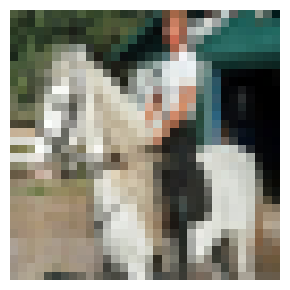

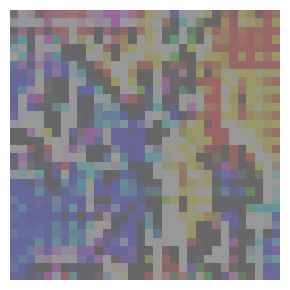

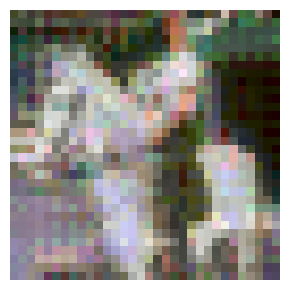


 PREPARANT COMBAT: A1 vs D10

--- IMATGE 1 ---
Classe Real:         horse
Predicció Original:  horse ✅ CORRECTA
Predicció Atacada:   horse ✅ CORRECTA
Epsilon aplicat:     0.2
--------------------


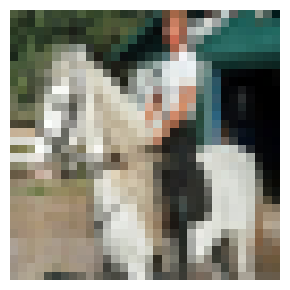

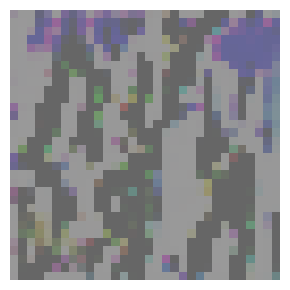

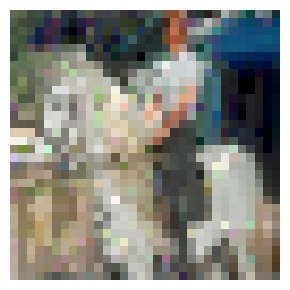


 PREPARANT COMBAT: A10 vs D1

--- IMATGE 1 ---
Classe Real:         horse
Predicció Original:  horse ✅ CORRECTA
Predicció Atacada:   cat ❌ INCORRECTA
Epsilon aplicat:     0.2
--------------------


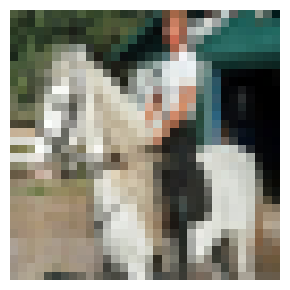

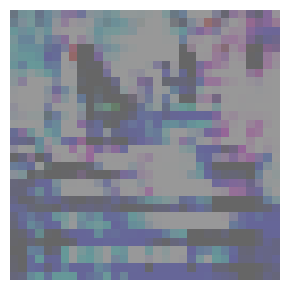

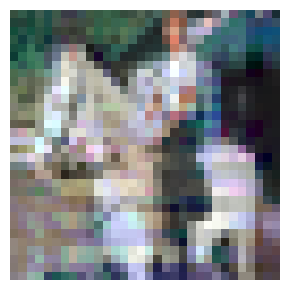


 PREPARANT COMBAT: A10 vs D10

--- IMATGE 1 ---
Classe Real:         horse
Predicció Original:  horse ✅ CORRECTA
Predicció Atacada:   dog ❌ INCORRECTA
Epsilon aplicat:     0.2
--------------------


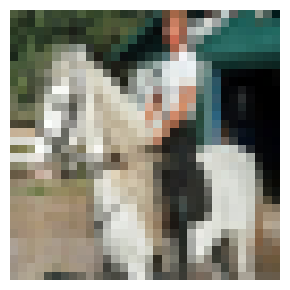

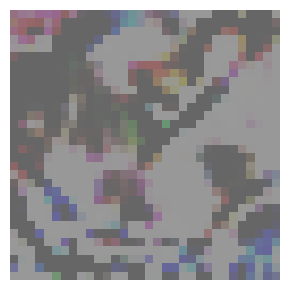

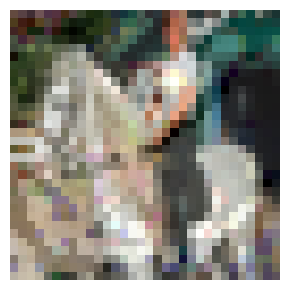

In [89]:
main_visualization()